In [15]:
import pandas as pd
df = pd.read_csv(r"C:\Users\sushm\Downloads\spam.csv", encoding='latin-1')

In [17]:
df.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [19]:
df.tail()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
5567,spam,This is the 2nd time we have tried 2 contact u...,NaN,NaN,NaN
5568,ham,Will Ì_ b going to esplanade fr home?,NaN,NaN,NaN
5569,ham,"Pity, * was in mood for that. So...any other s...",NaN,NaN,NaN
5570,ham,The guy did some bitching but I acted like i'd...,NaN,NaN,NaN
5571,ham,Rofl. Its true to its name,NaN,NaN,NaN


In [21]:
#here i selected only required columns
data = df[['v1', 'v2']]
data.columns = ['label', 'message']
data.head()

,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [23]:
# now converting labels into numeric values
data['label'] = data['label'].map({'ham': 0, 'spam': 1})
data.head()

C:\Users\sushm\AppData\Local\Temp\ipykernel_19936\1914806279.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['label'] = data['label'].map({'ham': 0, 'spam': 1})


,label,message
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


In [25]:
#This shows how many spam vs non-spam messages
data['label'].value_counts()

label
0    4825
1     747
Name: count, dtype: int64

In [27]:
import re
# simple text cleaning
def clean_text(text):
    text = text.lower()                      # lowercase
    text = re.sub(r'[^a-zA-Z]', ' ', text)   # remove symbols/numbers
    return text
data['message'] = data['message'].apply(clean_text)
data.head()

C:\Users\sushm\AppData\Local\Temp\ipykernel_19936\3386399315.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['message'] = data['message'].apply(clean_text)


,label,message
0,0,go until jurong point crazy available only ...
1,0,ok lar joking wif u oni
2,1,free entry in a wkly comp to win fa cup fina...
3,0,u dun say so early hor u c already then say
4,0,nah i don t think he goes to usf he lives aro...


In [32]:
!pip install nltk

In [33]:
#I removed stopwords to reduce noise and improve feature quality.
import nltk
from nltk.corpus import stopwords
nltk.download('stopwords')
stop_words = set(stopwords.words('english'))
# removing common words
def remove_stopwords(text):
    return " ".join([word for word in text.split() if word not in stop_words])
data['message'] = data['message'].apply(remove_stopwords)
data.head()

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\sushm\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.
C:\Users\sushm\AppData\Local\Temp\ipykernel_19936\3956401664.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['message'] = data['message'].apply(remove_stopwords)


,label,message
0,0,go jurong point crazy available bugis n great ...
1,0,ok lar joking wif u oni
2,1,free entry wkly comp win fa cup final tkts st ...
3,0,u dun say early hor u c already say
4,0,nah think goes usf lives around though


In [40]:
from sklearn.feature_extraction.text import TfidfVectorizer
vectorizer = TfidfVectorizer()
X = vectorizer.fit_transform(data['message'])  # features
y = data['label']                              # target
print(X.shape)

(5572, 7546)


In [64]:
#training the model
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

# splitting data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# training model
model = LogisticRegression()
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [66]:
from sklearn.metrics import accuracy_score
y_pred = model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.9560538116591928


In [68]:
#confusion matrix
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred)
print(cm)

[[958   2]
 [ 47 108]]


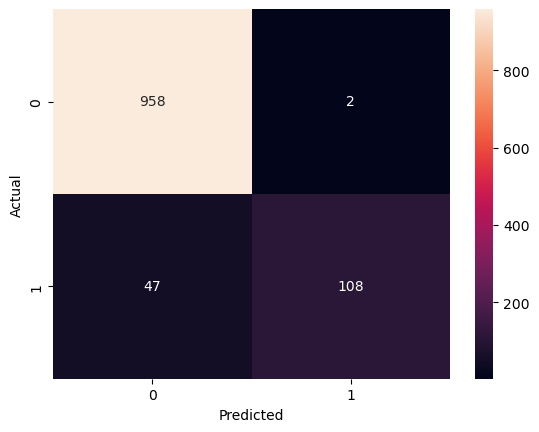

In [70]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [72]:
import pickle
# saving model
pickle.dump(model, open("model.pkl", "wb"))
# saving vectorizer (VERY IMPORTANT)
pickle.dump(vectorizer, open("vectorizer.pkl", "wb"))

In [76]:
samples = [
    "Win a free iPhone now!!!",
    "URGENT! Claim your prize",
    "Hey, are we meeting today?",
    "Call me when you are free"
]

for s in samples:
    vec = vectorizer.transform([s])
    pred = model.predict(vec)[0]
    print(s, "->", "Spam" if pred == 1 else "Not Spam")

#“The model performs well overall but misclassifies some edge cases due to dataset bias and limited contextual understanding.”

Win a free iPhone now!!! -> Not Spam
URGENT! Claim your prize -> Spam
Hey, are we meeting today? -> Not Spam
Call me when you are free -> Spam
